In [1]:
import os
import subprocess
import sys

import numpy as np

import matplotlib.pyplot as plt

from openfast_toolbox.io import FASTOutputFile
from openfast_toolbox.postpro import equivalent_load

# Add the directory containing utils.py to the Python path
utils_path = "/Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/Utils"
sys.path.append(utils_path)

# Now you can import the functions from utils.py
from utils import run_openfast, read_openfast_output, read_weis_output, readline_filterComments
from compute_damage_equivalent_load import compute_damage_equivalent_load

In [2]:
folder = "/Users/li/Desktop/Wind/WEIS/examples/06_IEA-15-240-RWT/outputs/06_IEA15_single_run/openfast_runs"
file_name0 = "weis_job_0.outb"
file_name1 = "weis_job_1.outb"
file_name2 = "weis_job_2.outb"
file_name3 = "weis_job_3.outb"

In [3]:
df0 = read_weis_output(folder, file_name0)
df1 = read_weis_output(folder, file_name1)
df2 = read_weis_output(folder, file_name2)
df3 = read_weis_output(folder, file_name3)

In [4]:
df1

,Time_[s],Wind1VelX_[m/s],Wind1VelY_[m/s],Wind1VelZ_[m/s],Azimuth_[deg],BldPitch1_[deg],BldPitch2_[deg],BldPitch3_[deg],GenSpeed_[rpm],LSSTipMya_[kN-m],...,M5N1FKze_[N],M5N1MKxe_[N*m],M5N1MKye_[N*m],M5N1MKze_[N*m],ReactFXss_[N],ReactFYss_[N],ReactFZss_[N],ReactMXss_[N*m],ReactMYss_[N*m],ReactMZss_[N*m]
0,5.00,12.878567,0.334485,-0.789916,224.782343,8.416072,8.416072,8.416072,7.592708,1653.058786,...,-1.881589e+07,1.811925e+06,1.118550e+08,-4.074891e+06,-9.107297e+05,2.376526e+06,-5.500388e+05,-5.165889e+07,-1.596443e+08,4.072872e+06
1,5.01,12.975357,0.370606,-0.821709,225.238274,8.420902,8.420902,8.420902,7.569010,1476.713141,...,-1.878233e+07,1.495768e+06,1.118040e+08,-4.476202e+06,-8.409651e+05,2.405995e+06,-5.845361e+05,-5.353136e+07,-1.584963e+08,4.473982e+06
2,5.02,13.072148,0.406561,-0.853601,225.688713,8.423551,8.423551,8.423551,7.549651,1664.080388,...,-1.879352e+07,4.025027e+06,1.113390e+08,-4.856561e+06,-8.329065e+05,1.905030e+06,-5.724155e+05,-4.893529e+07,-1.581551e+08,4.854521e+06
3,5.03,13.168938,0.442682,-0.885393,226.144645,8.424797,8.424797,8.424797,7.539971,2126.987705,...,-1.884479e+07,8.688347e+06,1.104217e+08,-5.197434e+06,-8.925403e+05,1.020974e+06,-5.211357e+05,-3.957292e+07,-1.586928e+08,5.196295e+06
4,5.04,13.265500,0.478803,-0.917285,226.595083,8.425732,8.425732,8.425732,7.541974,2766.240666,...,-1.892031e+07,1.422110e+07,1.091031e+08,-5.479480e+06,-1.011808e+06,1.904342e+04,-4.465468e+05,-2.867854e+07,-1.599908e+08,5.479525e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39996,404.96,14.757856,0.515761,1.373463,227.649769,9.119709,9.119709,9.119709,17.673168,74583.004333,...,-3.910557e+07,1.046396e+09,1.332173e+08,-1.523907e+07,-9.266509e+04,-1.639881e+08,1.973905e+07,1.969250e+09,-1.770037e+08,1.554920e+07
39997,404.97,14.621480,0.480141,1.286504,228.720934,9.139652,9.139652,9.139652,17.650471,-35974.693081,...,-2.992053e+07,-3.142664e+08,1.270032e+08,-1.695955e+07,-1.166763e+06,9.244711e+07,1.055437e+07,-9.754690e+08,-1.893781e+08,1.697405e+07
39998,404.98,14.485332,0.444354,1.199446,229.709702,9.159596,9.159596,9.159596,14.714217,-147072.449031,...,-6.020987e+06,-1.576841e+09,1.193017e+08,-1.839960e+07,-2.467654e+06,3.227290e+08,-1.334762e+07,-3.650722e+09,-2.044621e+08,1.810934e+07
39999,404.99,14.349185,0.408902,1.112685,230.451277,9.179695,9.179695,9.179695,9.707198,-211416.566018,...,1.521591e+07,-2.384860e+09,1.132723e+08,-1.920867e+07,-3.487875e+06,4.612606e+08,-3.458678e+07,-5.294413e+09,-2.162419e+08,1.870190e+07


In [5]:
df2

,Time_[s],Wind1VelX_[m/s],Wind1VelY_[m/s],Wind1VelZ_[m/s],Azimuth_[deg],BldPitch1_[deg],BldPitch2_[deg],BldPitch3_[deg],GenSpeed_[rpm],LSSTipMya_[kN-m],...,M5N1FKze_[N],M5N1MKxe_[N*m],M5N1MKye_[N*m],M5N1MKze_[N*m],ReactFXss_[N],ReactFYss_[N],ReactFZss_[N],ReactMXss_[N*m],ReactMYss_[N*m],ReactMZss_[N*m]
0,5.00,22.546581,-1.936969,-1.452926,224.569416,21.094099,21.094099,21.094099,7.618839,-204.667790,...,-1.875320e+07,6.883714e+06,9.501618e+07,-1.368799e+07,-3.949518e+05,1.992589e+06,-6.129785e+05,-4.280644e+07,-1.232663e+08,1.368611e+07
1,5.01,22.228287,-2.204098,-1.607594,225.025348,21.094313,21.094313,21.094313,7.596494,-238.610733,...,-1.873878e+07,6.326634e+06,9.528106e+07,-1.406456e+07,-3.027317e+05,1.963307e+06,-6.274002e+05,-4.246545e+07,-1.215706e+08,1.406354e+07
2,5.02,21.910312,-2.471227,-1.762262,225.481279,21.093671,21.093671,21.093671,7.578404,-1.010133,...,-1.876281e+07,8.475372e+06,9.509186e+07,-1.439976e+07,-2.771803e+05,1.436231e+06,-6.043255e+05,-3.615727e+07,-1.208936e+08,1.439841e+07
3,5.03,21.592018,-2.738618,-1.916752,225.931718,21.092496,21.092496,21.092496,7.569537,474.191068,...,-1.881857e+07,1.285243e+07,9.441075e+07,-1.467648e+07,-3.235840e+05,5.284888e+05,-5.476004e+05,-2.524581e+07,-1.212922e+08,1.467510e+07
4,5.04,21.273725,-3.005747,-2.071419,226.387650,21.091214,21.091214,21.091214,7.572374,1051.221098,...,-1.889452e+07,1.786615e+07,9.328315e+07,-1.488616e+07,-4.343068e+05,-4.817400e+05,-4.726078e+05,-1.297042e+07,-1.226778e+08,1.488511e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39996,404.96,24.919141,-4.838236,-3.375962,250.683871,23.025452,23.025452,23.025452,16.448585,80726.622457,...,-3.762249e+07,1.118020e+09,7.209321e+07,5.703222e+05,2.266508e+06,-1.813420e+08,1.825535e+07,2.177163e+09,-4.436042e+07,-4.351396e+05
39997,404.97,24.939830,-4.830125,-3.243872,251.689118,23.005473,23.005473,23.005473,16.666722,-74177.654737,...,-2.997459e+07,-2.196887e+08,6.133932e+07,-1.703362e+06,3.134394e+05,7.146412e+07,1.060803e+07,-7.230675e+08,-6.637889e+07,1.720223e+06
39998,404.98,24.960838,-4.821753,-3.111605,252.622955,22.985494,22.985494,22.985494,13.967148,-216975.615622,...,-7.412592e+06,-1.491901e+09,4.880699e+07,-3.619019e+06,-1.898961e+06,3.041974e+08,-1.195609e+07,-3.423994e+09,-9.180769e+07,3.512339e+06
39999,404.99,24.981527,-4.813381,-2.979693,253.320585,22.965515,22.965515,22.965515,9.123450,-299558.795758,...,1.396305e+07,-2.338344e+09,3.881367e+07,-4.664571e+06,-3.634108e+06,4.505342e+08,-3.333379e+07,-5.155165e+09,-1.120292e+08,4.464444e+06


In [6]:
df3

,Time_[s],Wind1VelX_[m/s],Wind1VelY_[m/s],Wind1VelZ_[m/s],Azimuth_[deg],BldPitch1_[deg],BldPitch2_[deg],BldPitch3_[deg],GenSpeed_[rpm],LSSTipMya_[kN-m],...,M5N1FKze_[N],M5N1MKxe_[N*m],M5N1MKye_[N*m],M5N1MKze_[N*m],ReactFXss_[N],ReactFYss_[N],ReactFZss_[N],ReactMXss_[N*m],ReactMYss_[N*m],ReactMZss_[N*m]
0,5.00,22.489066,3.127790,-0.212661,213.460923,20.426280,20.426280,20.426280,7.211221,-30541.060841,...,-1.857447e+07,5.628423e+06,1.390518e+08,-9.317949e+06,-8.049700e+05,2.514650e+06,-7.924993e+05,-6.146387e+07,-1.820476e+08,9.315525e+06
1,5.01,22.657360,3.388776,0.011401,213.894854,20.430111,20.430111,20.430111,7.186717,-30807.118299,...,-1.854753e+07,4.912923e+06,1.380571e+08,-9.598476e+06,-8.415019e+05,2.514650e+06,-8.194439e+05,-6.163417e+07,-1.832149e+08,9.595547e+06
2,5.02,22.825959,3.649763,0.235654,214.323293,20.432939,20.432939,20.432939,7.166537,-30703.008859,...,-1.855619e+07,6.979922e+06,1.366953e+08,-9.880570e+06,-9.317572e+05,1.989170e+06,-8.098208e+05,-5.550320e+07,-1.850647e+08,9.878698e+06
3,5.03,22.994253,3.910473,0.459717,214.751732,20.435038,20.435038,20.435038,7.156087,-30251.867952,...,-1.859372e+07,1.119342e+07,1.349629e+08,-1.015326e+07,-1.076273e+06,1.084175e+06,-7.732531e+05,-4.460371e+07,-1.875609e+08,1.015246e+07
4,5.04,23.162547,4.171459,0.683970,215.185663,20.437045,20.437045,20.437045,7.157889,-29569.372735,...,-1.864472e+07,1.612242e+07,1.329369e+08,-1.041028e+07,-1.263768e+06,6.240633e+04,-7.212885e+05,-3.217147e+07,-1.905181e+08,1.041058e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39996,404.96,19.221963,-0.816280,3.413615,212.021809,22.718446,22.718446,22.718446,16.103620,36516.986185,...,-3.950832e+07,1.058367e+09,5.778921e+07,-1.197904e+07,2.171177e+05,-1.689235e+08,2.014155e+07,2.033453e+09,-6.702804e+07,1.210480e+07
39997,404.97,19.237512,-0.860192,3.442717,213.005020,22.698376,22.698376,22.698376,16.163078,-29257.044415,...,-3.098274e+07,-2.861365e+08,4.849004e+07,-1.398347e+07,-1.352411e+06,8.467942e+07,1.161646e+07,-8.772230e+08,-8.607027e+07,1.399142e+07
39998,404.98,19.252756,-0.904104,3.471628,213.900347,22.678396,22.678396,22.678396,13.326390,-107801.832979,...,-7.460431e+06,-1.544383e+09,4.007874e+07,-1.557574e+07,-2.838132e+06,3.144021e+08,-1.190812e+07,-3.544534e+09,-1.041248e+08,1.546037e+07
39999,404.99,19.268305,-0.947740,3.500539,214.564976,22.658417,22.658417,22.658417,8.405427,-157797.499573,...,1.421628e+07,-2.360688e+09,3.565279e+07,-1.626373e+07,-3.703616e+06,4.547931e+08,-3.358603e+07,-5.207899e+09,-1.149060e+08,1.605483e+07


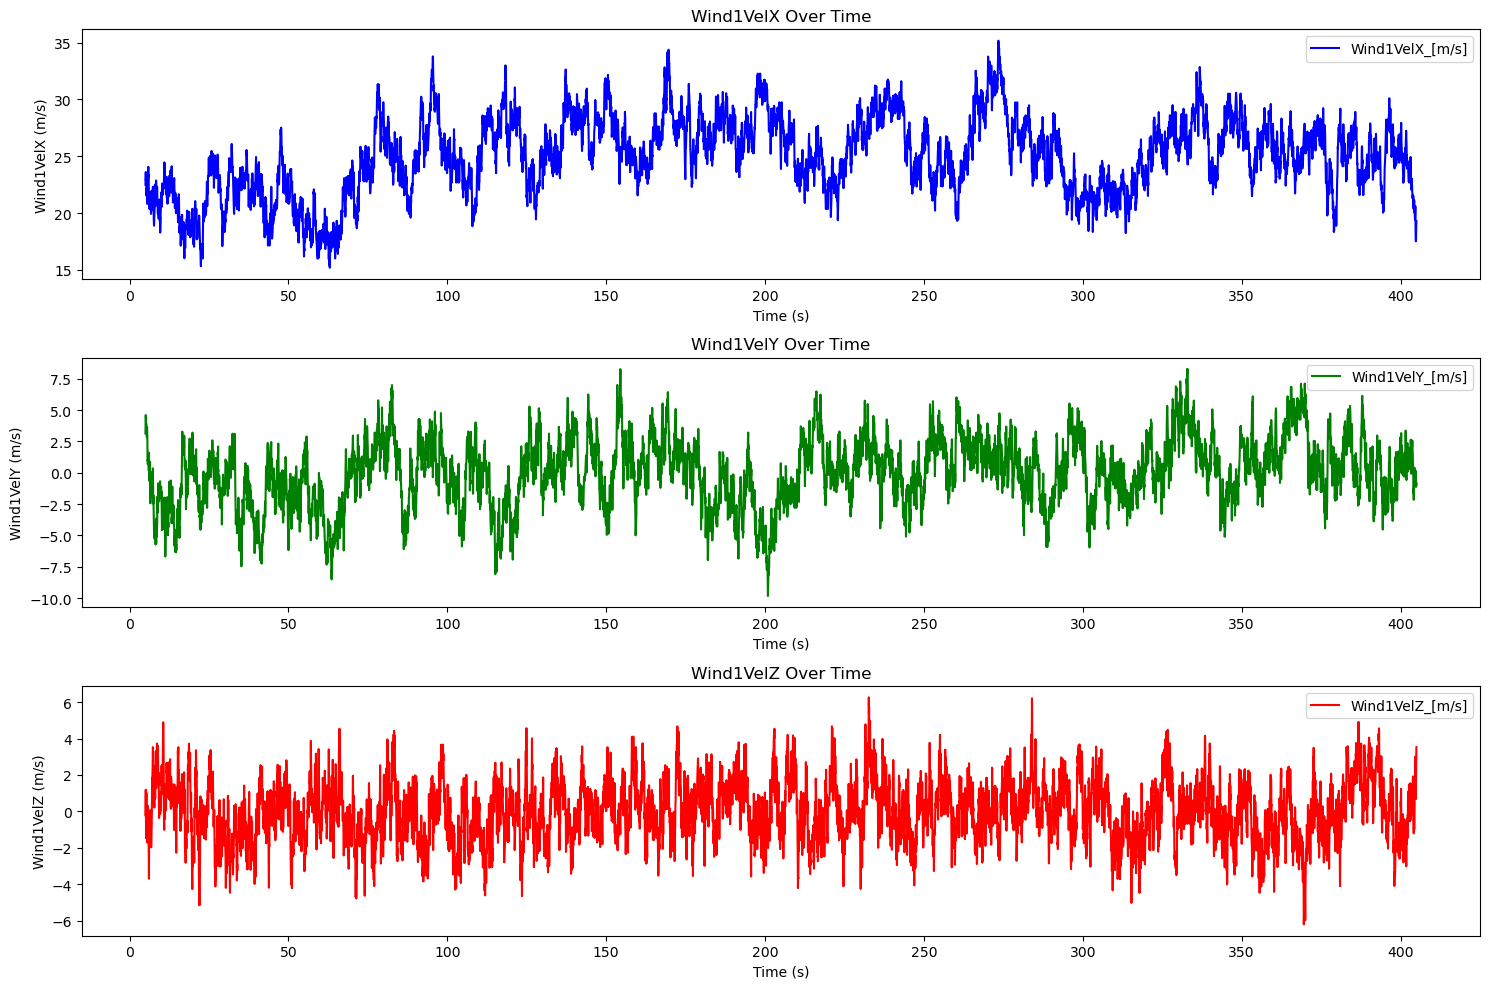

In [7]:
# Create the plots
plt.figure(figsize=(15, 10))

# Plot Wind1VelX_[m/s] over Time_[s]
plt.subplot(3, 1, 1)
plt.plot(df3['Time_[s]'], df3['Wind1VelX_[m/s]'], label='Wind1VelX_[m/s]', color='b')
plt.xlabel('Time (s)')
plt.ylabel('Wind1VelX (m/s)')
plt.title('Wind1VelX Over Time')
plt.legend()

# Plot Wind1VelY_[m/s] over Time_[s]
plt.subplot(3, 1, 2)
plt.plot(df3['Time_[s]'], df3['Wind1VelY_[m/s]'], label='Wind1VelY_[m/s]', color='g')
plt.xlabel('Time (s)')
plt.ylabel('Wind1VelY (m/s)')
plt.title('Wind1VelY Over Time')
plt.legend()

# Plot Wind1VelZ_[m/s] over Time_[s]
plt.subplot(3, 1, 3)
plt.plot(df3['Time_[s]'], df3['Wind1VelZ_[m/s]'], label='Wind1VelZ_[m/s]', color='r')
plt.xlabel('Time (s)')
plt.ylabel('Wind1VelZ (m/s)')
plt.title('Wind1VelZ Over Time')
plt.legend()

# Adjust layout and show the plots
plt.tight_layout()
plt.show()

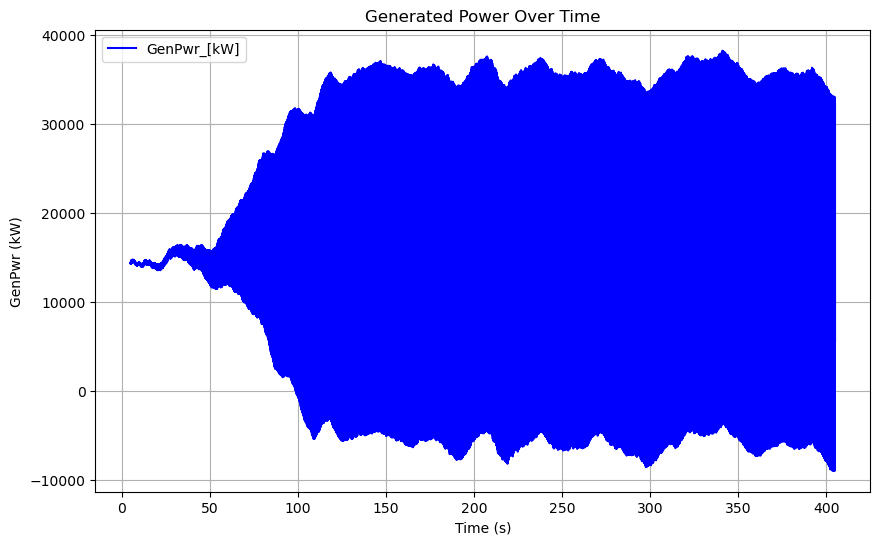

In [8]:
# Create the plot for GenPwr_[kW] over Time_[s]
plt.figure(figsize=(10, 6))
plt.plot(df3['Time_[s]'], df3['GenPwr_[kW]'], label='GenPwr_[kW]', color='b')
plt.xlabel('Time (s)')
plt.ylabel('GenPwr (kW)')
plt.title('Generated Power Over Time')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

In [20]:
# df3.to_pickle("/Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/Outputs/IEA15MW.pkl")
df1.to_pickle("/Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/Outputs/IEA15MW.pkl")

Leq: 448666.35198562726


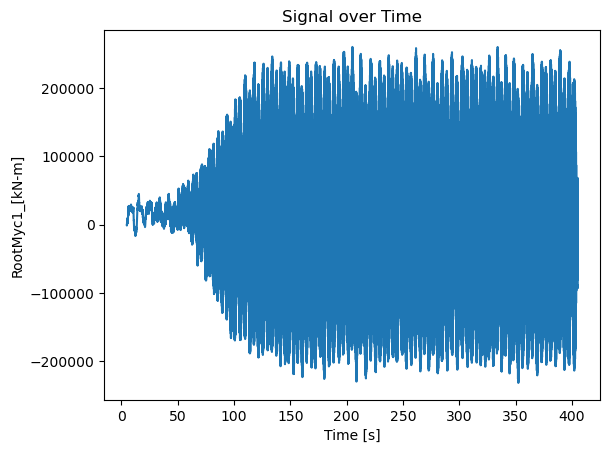

In [10]:
# Define the parameters
fastout_filename = '/Users/li/Desktop/Wind/WEIS/examples/06_IEA-15-240-RWT/outputs/06_IEA15_single_run/openfast_runs/weis_job_3.outb'
signal_column = 'RootMyc1_[kN-m]'
wohler_exponent = 10

# Compute the damage equivalent load
Leq, df = compute_damage_equivalent_load(fastout_filename, signal_column, wohler_exponent)
print('Leq:', Leq)

plt.plot(df['Time_[s]'], df[signal_column])
plt.xlabel('Time [s]')
plt.ylabel(signal_column)
plt.title('Signal over Time')
plt.show()

In [29]:
df0['RtFldCp_[-]'].describe()

count    40001.000000
mean         0.009782
std          0.033629
min         -0.048561
25%          0.002940
50%          0.008408
75%          0.012126
max          0.415624
Name: RtFldCp_[-], dtype: float64